# B2B Sales Funnel Analysis & Lead Scoring Model



This notebook analyses the sales funnel to find where leads drop off and builds a model to score which leads are most likely to book a meeting.

**Dataset:** 1000 B2B outreach leads with region, industry, channel, touches, and outcome data.


Import Libraries

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Load & Understand Data

In [5]:
df = pd.read_csv("C:/Users/chand/OneDrive/Desktop/B2B_leads_campaign/raw/leads.csv")
df.head()

,lead_id,region,industry,company_size,outreach_channel,num_touches,email_opened,response_received,days_to_respond,meeting_booked,funnel_stage
0,1,EMEA,Healthcare,Mid,Email,5,0,1,8,0,Engaged
1,2,APAC,Finance,Small,Email,5,0,0,13,0,Prospect
2,3,US,Retail,Mid,Linkedin,7,0,1,4,1,Meeting Booked
3,4,UK,IT Services,Small,Email,5,0,0,9,0,Prospect
4,5,GCC,Retail,Enterprise,Linkedin,8,1,1,9,1,Meeting Booked


In [6]:
#Checking for dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   lead_id            1000 non-null   int64 
 1   region             1000 non-null   object
 2   industry           1000 non-null   object
 3   company_size       1000 non-null   object
 4   outreach_channel   1000 non-null   object
 5   num_touches        1000 non-null   int64 
 6   email_opened       1000 non-null   int64 
 7   response_received  1000 non-null   int64 
 8   days_to_respond    1000 non-null   int64 
 9   meeting_booked     1000 non-null   int64 
 10  funnel_stage       1000 non-null   object
dtypes: int64(6), object(5)
memory usage: 86.1+ KB


In [7]:
#Checking for missing values & Understanding the values
df.describe(include = 'all')

,lead_id,region,industry,company_size,outreach_channel,num_touches,email_opened,response_received,days_to_respond,meeting_booked,funnel_stage
count,1000.000000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000
unique,NaN,5,5,3,2,NaN,NaN,NaN,NaN,NaN,4
top,NaN,GCC,Retail,Mid,Email,NaN,NaN,NaN,NaN,NaN,Prospect
freq,NaN,269,214,403,585,NaN,NaN,NaN,NaN,NaN,420
mean,500.500000,NaN,NaN,NaN,NaN,5.090000,0.329000,0.253000,15.05800,0.329000,NaN
std,288.819436,NaN,NaN,NaN,NaN,2.528298,0.470085,0.434948,8.28307,0.470085,NaN
min,1.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,1.00000,0.000000,NaN
25%,250.750000,NaN,NaN,NaN,NaN,3.000000,0.000000,0.000000,8.75000,0.000000,NaN
50%,500.500000,NaN,NaN,NaN,NaN,5.000000,0.000000,0.000000,15.00000,0.000000,NaN
75%,750.250000,NaN,NaN,NaN,NaN,7.000000,1.000000,1.000000,22.00000,1.000000,NaN


In [8]:
#Checking for duplicate rows
df.duplicated().sum()
           

0

<Axes: >

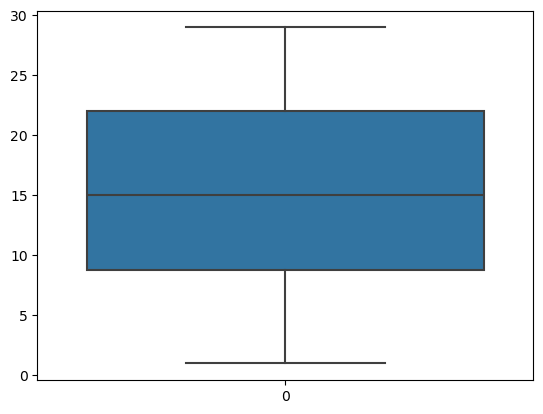

In [9]:
#Days_to_respond std is >1 so looking for Outliers
sns.boxplot(df['days_to_respond'])

No outliers

<Axes: >

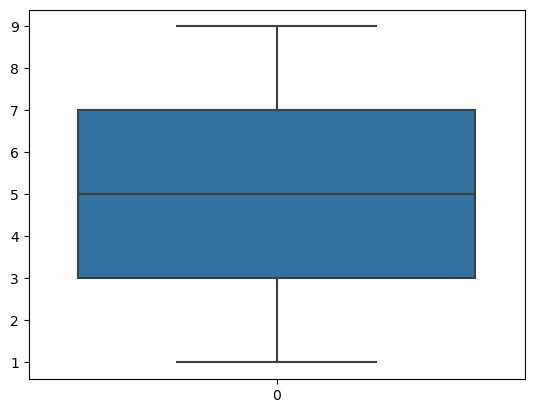

In [10]:
#Num_touches std >1 , so looking for Outliers
sns.boxplot(df['num_touches'])

No outlier

region
GCC     41.263941
US      34.497817
APAC    34.000000
EMEA    26.562500
UK      25.714286
Name: meeting_booked, dtype: float64

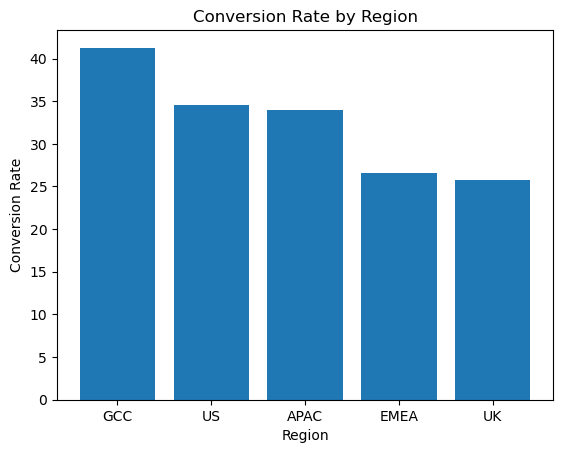

In [11]:
# Which region converts best?
region_conv = df.groupby("region")["meeting_booked"].mean().mul(100).sort_values(ascending = False)
plt.bar(region_conv.index, region_conv.values)
plt.title("Conversion Rate by Region")
plt.ylabel("Conversion Rate")
plt.xlabel("Region")

region_conv

- GCC, US & APAC show the highest meeting conversion rates

industry
IT Services    44.041451
SaaS           37.264151
Retail         29.906542
Finance        27.745665
Healthcare     25.480769
Name: meeting_booked, dtype: float64

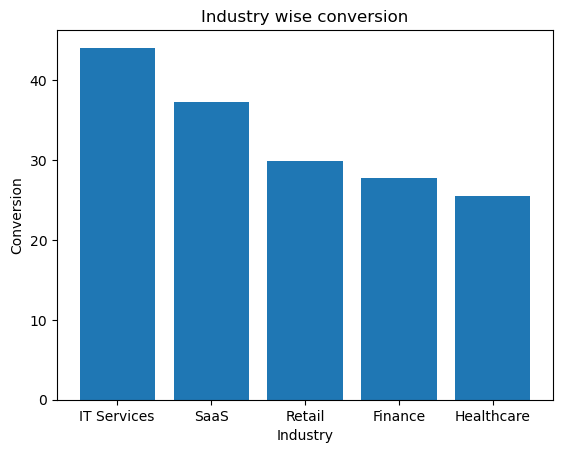

In [12]:
# Which Industry Conversion is better ? 
industry_conv = df.groupby('industry')['meeting_booked'].mean().mul(100).sort_values(ascending= False)
plt.bar(industry_conv.index, industry_conv.values)
plt.title('Industry wise conversion')
plt.xlabel('Industry')
plt.ylabel('Conversion')

industry_conv

- IT Services and SaaS industries respond best

outreach_channel
Linkedin    0.346988
Email       0.316239
Name: meeting_booked, dtype: float64

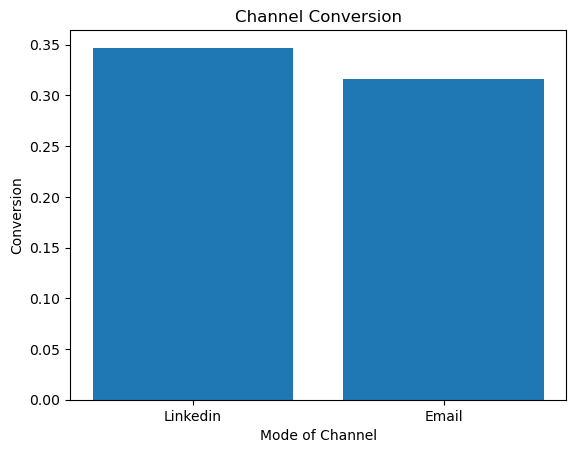

In [13]:
# which outreach channel is best? Linkedin or Email

channel_conv = df.groupby("outreach_channel")["meeting_booked"].mean().sort_values(ascending= False)
plt.bar(channel_conv.index, channel_conv.values)
plt.title('Channel Conversion')
plt.xlabel('Mode of Channel')
plt.ylabel('Conversion')

channel_conv

- Linkedin outperforms Email for meeting conversion

Text(0, 0.5, 'Conversion')

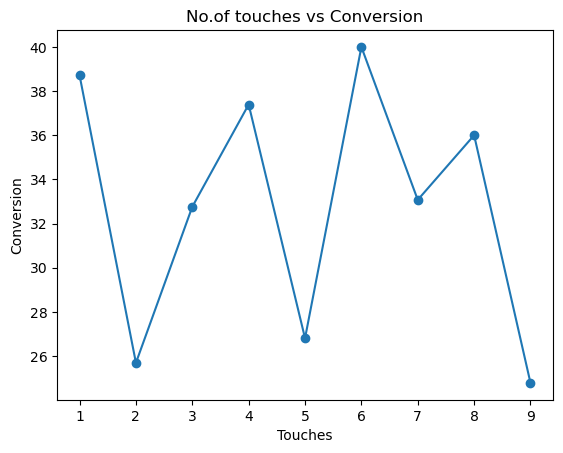

In [14]:
#num_touches vs conversion
click_rate = df.groupby('num_touches')['meeting_booked'].mean().mul(100).sort_index(ascending= True)
plt.plot(click_rate.index,click_rate.values, marker = 'o')
plt.title('No.of touches vs Conversion')
plt.xlabel('Touches')
plt.ylabel('Conversion')

- Touches didn't prove anything

In [15]:
df.groupby('funnel_stage').count()

,lead_id,region,industry,company_size,outreach_channel,num_touches,email_opened,response_received,days_to_respond,meeting_booked
funnel_stage,,,,,,,,,,
Contacted,165,165,165,165,165,165,165,165,165,165
Engaged,86,86,86,86,86,86,86,86,86,86
Meeting Booked,329,329,329,329,329,329,329,329,329,329
Prospect,420,420,420,420,420,420,420,420,420,420


In [16]:
#Regional & industry wise split for understanding which industry & outreach channel tops
regional_split = df.groupby(['industry','outreach_channel']).agg({'days_to_respond': 'median', 'meeting_booked': 'mean'}).sort_values(by='meeting_booked',ascending= False)
regional_split

days_to_respond  meeting_booked
industry    outreach_channel                                 
IT Services Linkedin                     14.5        0.450000
            Email                        13.0        0.433628
SaaS        Linkedin                     13.0        0.376471
            Email                        16.0        0.370079
Finance     Linkedin                     15.5        0.318182
Retail      Linkedin                     15.0        0.313131
            Email                        15.0        0.286957
Healthcare  Linkedin                     16.0        0.282353
Finance     Email                        14.0        0.252336
Healthcare  Email                        14.0        0.235772

IT services & SaaS outreach channel outperforms the best

In [17]:
# Using Shapiro to understand the Normal distribution & p-value
norm_dist = shapiro(df['meeting_booked'])
norm_dist

ShapiroResult(statistic=0.592597484588623, pvalue=2.872661851865875e-43)

p-value > 0.05 #failed to reject HO

In [18]:
#Using Chi2 to check outreach_channel & meeting _booked has a null hypothesis
contingency = pd.crosstab(df['meeting_booked'], df['outreach_channel'])
chi2,p,dof,expected = chi2_contingency(contingency)
print(f'chi2: {chi2}')
print(f'p-value: {p}')
print(f'dof: {dof}')
print(f'expected: {expected}')

chi2: 0.9051485511913886
p-value: 0.3414049362507295
dof: 1
expected: [[392.535 278.465]
 [192.465 136.535]]


p-value >= 0.05 #failed to reject HO

In [19]:
#Using Chi2 to check region & meeting _booked has a null hypothesis
contingency_1 = pd.crosstab(df['meeting_booked'], df['region'])
chi2,p,dof,expected = chi2_contingency(contingency_1)
print(f'chi2: {chi2}')
print(f'p-value: {p}')
print(f'dof: {dof}')
print(f'expected: {expected}')

chi2: 17.248847714384276
p-value: 0.001729159480767245
dof: 4
expected: [[ 67.1   128.832 180.499 140.91  153.659]
 [ 32.9    63.168  88.501  69.09   75.341]]


p-value < 0.05 #reject HO

In [20]:
#Using Chi2 to check industry & meeting _booked has a null hypothesis
contingency_2 = pd.crosstab(df['meeting_booked'], df['industry'])
chi2,p,dof,expected = chi2_contingency(contingency_2)
print(f'chi2: {chi2}')
print(f'p-value: {p}')
print(f'dof: {dof}')
print(f'expected: {expected}')

chi2: 20.818295468111522
p-value: 0.000344047004952954
dof: 4
expected: [[116.083 139.568 129.503 143.594 142.252]
 [ 56.917  68.432  63.497  70.406  69.748]]


p-value < 0.05 #reject HO

In [21]:
#Encoding for Model Training

df_model= df.copy()
df_model = pd.get_dummies(df_model,columns=['region','industry','company_size','outreach_channel'], drop_first= True)

df_model.drop(columns=['lead_id','funnel_stage'], inplace= True)

df_model.head()



,num_touches,email_opened,response_received,days_to_respond,meeting_booked,region_EMEA,region_GCC,region_UK,region_US,industry_Healthcare,industry_IT Services,industry_Retail,industry_SaaS,company_size_Mid,company_size_Small,outreach_channel_Linkedin
0,5,0,1,8,0,True,False,False,False,True,False,False,False,True,False,False
1,5,0,0,13,0,False,False,False,False,False,False,False,False,False,True,False
2,7,0,1,4,1,False,False,False,True,False,False,True,False,True,False,True
3,5,0,0,9,0,False,False,True,False,False,True,False,False,False,True,False
4,8,1,1,9,1,False,True,False,False,False,False,True,False,False,False,True


In [22]:
# ML Model Selection Logistic Regression

X = df_model.drop(columns=['meeting_booked'])
y = df_model['meeting_booked']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

model = LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
model.score(X_test, y_test)



0.735

In [23]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.74      0.86      0.79       118
           1       0.73      0.56      0.63        82

    accuracy                           0.73       200
   macro avg       0.73      0.71      0.71       200
weighted avg       0.73      0.73      0.73       200



In [24]:
#Random Forest Classifier
model_1 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced',max_depth= 5)
model_1.fit(X_train,y_train)
y1_pred = model_1.predict(X_test)
model_1.score(X_test,y_test)

0.71

In [25]:
print(classification_report(y1_pred, y_test, target_names=['meeting_booked','no_meeting_booked']))

                   precision    recall  f1-score   support

   meeting_booked       0.75      0.81      0.78       127
no_meeting_booked       0.62      0.53      0.57        73

         accuracy                           0.71       200
        macro avg       0.69      0.67      0.68       200
     weighted avg       0.70      0.71      0.70       200



Text(0.5, 1.0, 'Random Forest')

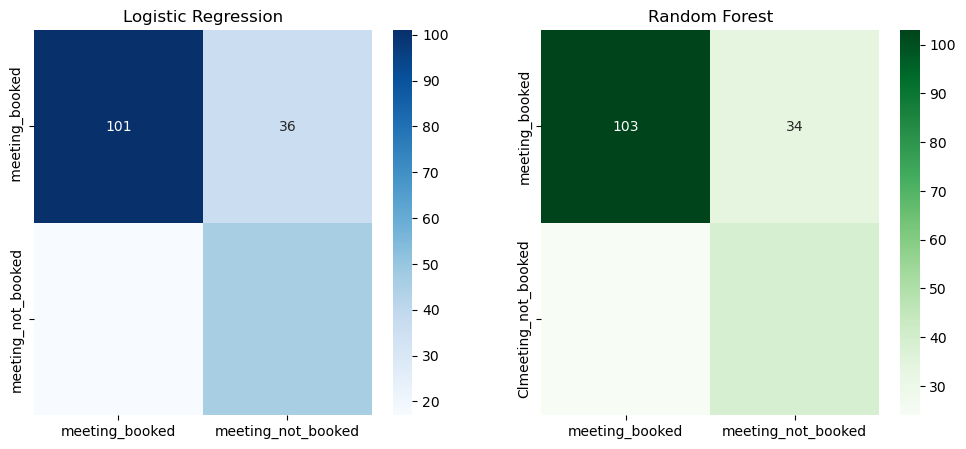

In [26]:
# Understanding both models with Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["meeting_booked","meeting_not_booked"], yticklabels=[" meeting_booked","meeting_not_booked"], ax=axes[0])
axes[0].set_title("Logistic Regression")

sns.heatmap(confusion_matrix(y_test, y1_pred), annot=True, fmt="d", cmap="Greens",
            xticklabels=["meeting_booked","meeting_not_booked"], yticklabels=["meeting_booked","Clmeeting_not_booked"], ax=axes[1])
axes[1].set_title("Random Forest")

What Drives Meeting Conversion most with Random Forest

response_received     0.371858
days_to_respond       0.119789
email_opened          0.110975
num_touches           0.090384
company_size_Small    0.047845
dtype: float64

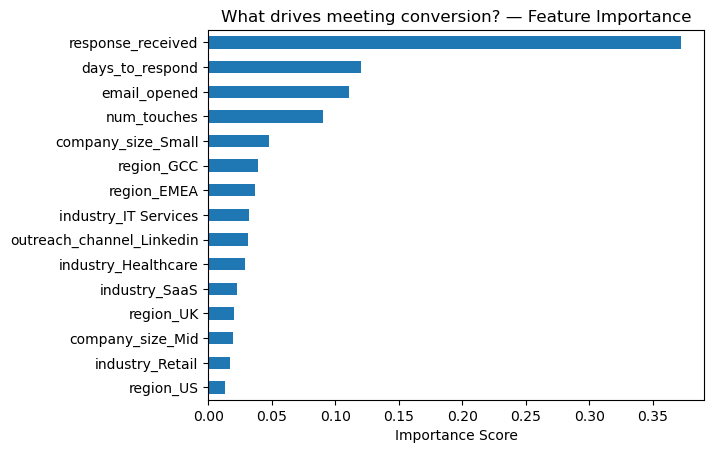

In [27]:
importance = pd.Series(model_1.feature_importances_, index=X.columns).sort_values(ascending=True)
importance.plot(kind="barh")
plt.title("What drives meeting conversion? — Feature Importance")
plt.xlabel("Importance Score")

importance.sort_values(ascending=False).head(5)


- Lead Scores. Due to model.predict() it gives you just 0 or 1. 

In [33]:
# Get probability instead of just 0 or 1
y_proba = model_1.predict_proba(X_test)[:, 1]

# Turn probability into High / Medium /  Low
lead_scores = pd.DataFrame({
    "actual"  : y_test.values,
    "score"   : y_proba.round(3),
    "priority": pd.cut(y_proba, bins=[0, 0.3, 0.6, 1.0], labels=["Low", "Medium", "High"])
}).sort_values("score", ascending=False)

print("Priority breakdown:")
print(lead_scores["priority"].value_counts())
print()
lead_scores.head(10)

Priority breakdown:
priority
Medium    124
High       46
Low        30
Name: count, dtype: int64



,actual,score,priority
177,1,0.820,High
96,1,0.814,High
16,1,0.807,High
182,1,0.789,High
13,1,0.786,High
128,1,0.786,High
176,0,0.768,High
173,1,0.764,High
92,0,0.760,High
28,1,0.757,High


## Summary

**What I did:**
1. Created a realistic B2B outreach dataset (1000 leads)
2. Analysed the sales funnel — found where leads drop off
3. Identified which regions, channels, and industries convert best
4. Built two ML models to predict which leads will book a meeting
5. Scored every lead as High / Medium / Low priority

**Key findings:**
- GCC, US and APAC have the highest meeting conversion rates
- Linkedin outperforms Email for converting leads to meetings
- IT Services and SaaS respond best to outreach
- Responding to outreach is the single strongest predictor of booking a meeting


**Stats & Models used:**
- Shapiro test — used to identify normal distribution and p-value
- Chi2 test — categorical vs categorical segmentation and p-value to understand ho
- Logistic Regression — simple and explainable
- Random Forest — more powerful, used for final lead scoring
